In [3]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent

assert (ROOT / 'scripts').exists(), f'Project root not found: {ROOT}'

## Метрики на SVHN test

In [4]:
metrics_path = ROOT / 'runs' / 'eval' / 'svhn_full_e8_from_e5_test_metrics.json'
metrics = json.loads(metrics_path.read_text(encoding='utf-8'))

for key, value in metrics.items():
    print(f'{key:>10}: {value:.4f}')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/maxim-bovt/PycharmProjects/CV/ITMO-cv-labs-bovt/runs/eval/svhn_full_e8_from_e5_test_metrics.json'

## Графики обучения

FileNotFoundError: [Errno 2] No such file or directory: '/Users/maxim-bovt/PycharmProjects/CV/ITMO-cv-labs-bovt/runs/detect/svhn_full_e8_from_e5/results.png'

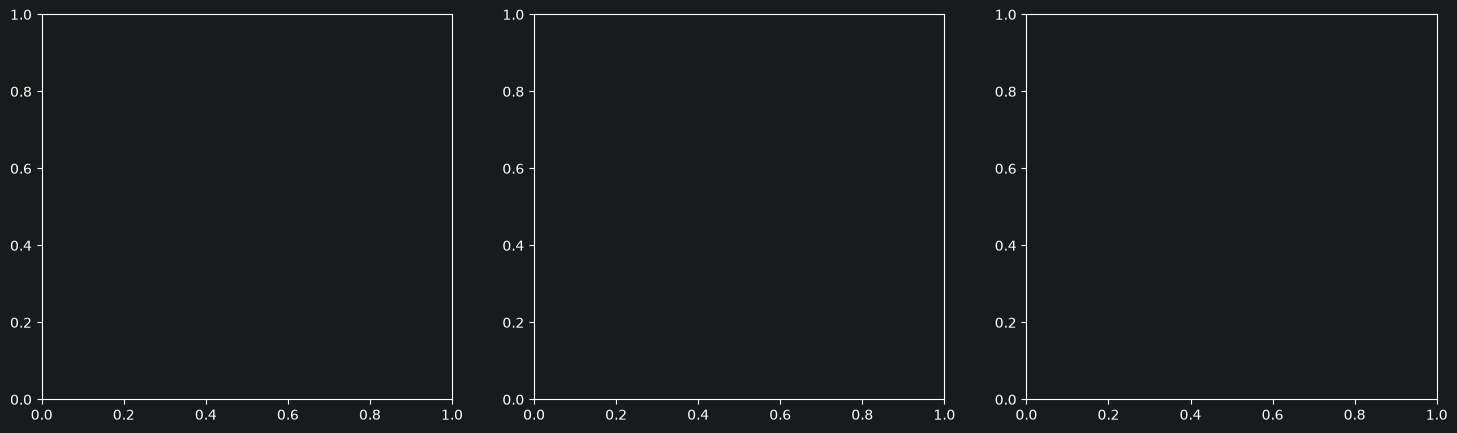

In [5]:
artifacts_dir = ROOT / 'runs' / 'detect' / 'svhn_full_e8_from_e5'
image_paths = [
    artifacts_dir / 'results.png',
    artifacts_dir / 'BoxPR_curve.png',
    artifacts_dir / 'confusion_matrix.png',
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, path in zip(axes, image_paths):
    ax.imshow(Image.open(path))
    ax.set_title(path.name)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Предсказания на пользовательских фото

In [6]:
predictions_path = ROOT / 'runs' / 'predict' / 'custom' / 'predictions.json'
predictions = json.loads(predictions_path.read_text(encoding='utf-8'))
predictions

FileNotFoundError: [Errno 2] No such file or directory: '/Users/maxim-bovt/PycharmProjects/CV/ITMO-cv-labs-bovt/runs/predict/custom/predictions.json'

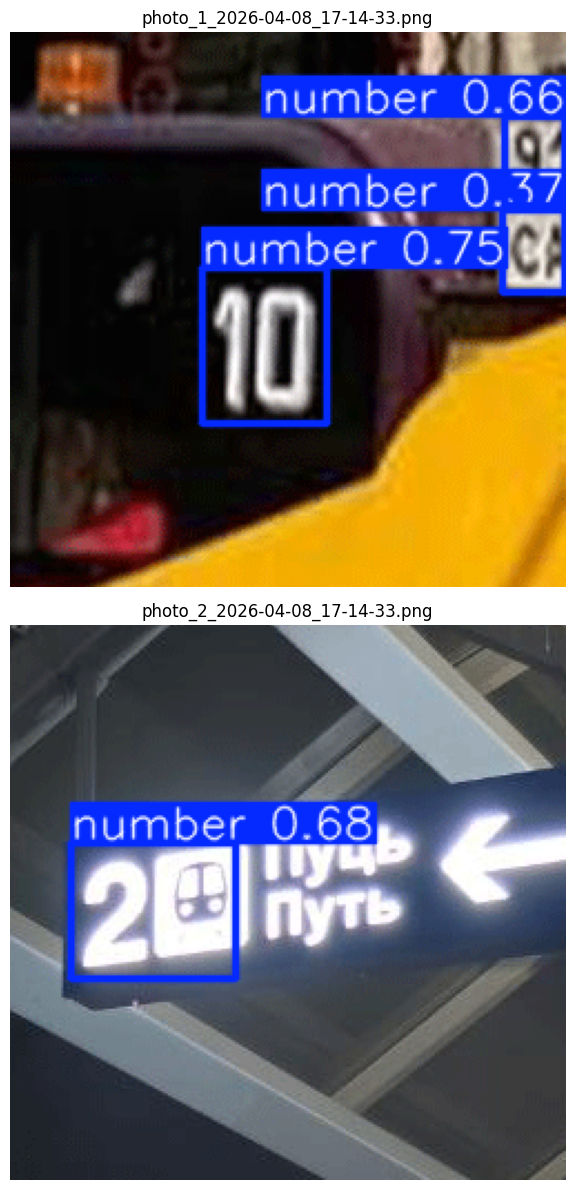

In [6]:
predicted_images_dir = ROOT / 'runs' / 'predict' / 'custom'
predicted_images = sorted(path for path in predicted_images_dir.glob('*.png'))

if not predicted_images:
    display(Markdown('Предсказанные изображения не найдены. Сначала выполните `scripts/predict.py`.'))
else:
    fig, axes = plt.subplots(len(predicted_images), 1, figsize=(12, 6 * len(predicted_images)))
    if len(predicted_images) == 1:
        axes = [axes]
    for ax, path in zip(axes, predicted_images):
        ax.imshow(Image.open(path))
        ax.set_title(path.name)
        ax.axis('off')
    plt.tight_layout()
    plt.show()